# Gilt Biography: 8¾% Treasury 1997

*Generated from the Ellison-Scott UK government bond (gilt) database: 502 stocks, amounts outstanding 1946-2023, month-end prices 1975-2023.*

**L1 ID:** 20100  
**Instrument code:** 8TTY97  
**ISIN:** GB0009032060  
**Category:** Conventional > Treasury > Conventional, maturing 1990s

**Contents:** At a Glance · Overview · The Instrument · Historical Context · Lifecycle Timeline · Issuance and Amount Outstanding · Market Price · Yield and Relative Value · On the Yield Curve · Returns and Risk to Holders · Market Events · Related Stocks · Issuance, Distribution and Redemption · Implications and Legacy · Data Notes · References

---

### Setup

The first code cell holds the helper functions shared by every chapter (loading the database, yields, index ratios, peer statistics, total returns). The second loads this gilt's series. The database file `UK_Gilts_Bond_Database.xlsx` must be in the notebook's folder or a parent folder, or its path set in the `UK_GILTS_DB` environment variable.

In [1]:
# ── UK gilt helpers (shared by the generator and every chapter notebook) ──────
import os
import re
import calendar
from pathlib import Path
import numpy as np
import pandas as pd

DB_FILENAME = "UK_Gilts_Bond_Database.xlsx"


def locate_database(start=None):
    """Find the database: $UK_GILTS_DB, else the current folder or up to three parents."""
    env = os.environ.get("UK_GILTS_DB")
    if env and Path(env).exists():
        return Path(env)
    here = Path(start or Path.cwd()).resolve()
    for d in [here, *here.parents][:4]:
        if (d / DB_FILENAME).exists():
            return d / DB_FILENAME
    raise FileNotFoundError(f"{DB_FILENAME} not found; set the UK_GILTS_DB environment variable")


def _wide(df):
    out = df.set_index(["L1 ID", "Series"]).T
    out.index = pd.to_datetime(out.index)
    return out.apply(pd.to_numeric, errors="coerce")


def load_database(path=None):
    """Load BondList, prices, quantities, RPI and the correction log from the Excel database."""
    path = Path(path) if path else locate_database()
    sh = pd.read_excel(path, sheet_name=["BondList", "BondPrice", "BondQuant", "RPI", "Corrections"])
    rpi = sh["RPI"]
    rpi = pd.Series(rpi.iloc[:, 1].values, index=pd.to_datetime(rpi.iloc[:, 0]) + pd.offsets.MonthEnd(0))
    return {"list": sh["BondList"].set_index("L1 ID"), "price": _wide(sh["BondPrice"]),
            "quant": _wide(sh["BondQuant"]), "rpi": rpi, "corrections": sh["Corrections"], "path": path}


def series(db, kind, bond_id, name):
    """kind = 'price' or 'quant'; name = 'Average', 'Partly Paid', 'Total Outstanding', 'Indexed Outstanding'."""
    df = db[kind]
    if (bond_id, name) not in df.columns:
        return pd.Series(dtype=float)
    return df[(bond_id, name)].dropna()


# Before 28 February 1986 (when the Accrued Income Scheme began) stocks with more than five years to final
# maturity, and undated stocks, were quoted with accrued interest included ("dirty"): their prices drop by about
# half a coupon when they go ex-dividend. Shorter stocks were already quoted clean, as all stocks are since.
DIRTY_BEFORE = pd.Timestamp("1986-02-28")
DIRTY_MIN_YEARS = 5.0
EX_DIV_DAYS = 35          # ex-dividend about five weeks before each coupon (35 days before the quote date fits best)
_MONTHS = {m: k for k, m in enumerate(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct",
                                       "Nov", "Dec"], 1)}


def coupon_schedule(row, start, end):
    """Coupon dates around [start, end]: from 'Payment Dates' (e.g. '1 Mar / 1 Sep'), else back from the final date."""
    dates = []
    txt = row.get("Payment Dates")
    if isinstance(txt, str):
        for part in txt.split("/"):
            bits = part.split()
            if len(bits) == 2 and bits[0].isdigit() and bits[1][:3] in _MONTHS:
                m = _MONTHS[bits[1][:3]]
                for y in range(start.year - 1, end.year + 2):
                    dates.append(pd.Timestamp(y, m, min(int(bits[0]), calendar.monthrange(y, m)[1])))
    if not dates and pd.notna(row.get("Payable Date")):
        step = 12 // (int(row["Coupons Per Year"]) if pd.notna(row.get("Coupons Per Year")) else 2)
        mat, k = pd.Timestamp(row["Payable Date"]), 0
        while mat - pd.DateOffset(months=step * k) >= start - pd.DateOffset(years=1):
            dates.append(mat - pd.DateOffset(months=step * k))
            k += 1
    return sorted(set(dates))


def clean_price(db, bond_id):
    """Fully-paid month-end price on a clean basis. Dirty source prices (before 28 Feb 1986, more than five years
    to final maturity or undated) are converted: clean = dirty - accrued interest when cum-dividend, and
    dirty + rebate interest when ex-dividend. Index-linked coupons are uplifted by the index ratio."""
    row = db["list"].loc[bond_id]
    p = series(db, "price", bond_id, "Average")
    c = row["Coupon Rate"]
    if p.empty or pd.isna(c):
        return p
    old = np.asarray(p.index < DIRTY_BEFORE)
    if pd.notna(row.get("Payable Date")):
        old &= np.asarray((pd.Timestamp(row["Payable Date"]) - p.index).days / 365.25 > DIRTY_MIN_YEARS)
    if not old.any():
        return p
    cds = coupon_schedule(row, p.index[old].min(), DIRTY_BEFORE)
    if len(cds) < 2:
        return p
    cdn = np.array([x.value for x in cds], dtype=np.int64)
    quote = p.index[old].map(pd.offsets.BMonthEnd().rollback)   # prices are taken on the last business day
    d = pd.DatetimeIndex(quote).values.astype("datetime64[ns]").astype(np.int64)
    nx = np.clip(np.searchsorted(cdn, d, side="right"), 1, len(cdn) - 1)
    prev, nxt = cdn[nx - 1], cdn[nx]
    a = (d - prev) / (nxt - prev)
    freq = int(row["Coupons Per Year"]) if pd.notna(row.get("Coupons Per Year")) else 2
    cpn = np.full(len(d), c / freq)
    if row["Category L1"] == "Index-linked":
        cpn = cpn * index_ratio(db, bond_id, p.index[old]).values
    ex = d > nxt - EX_DIV_DAYS * 86400 * 10**9
    adj = np.where(ex, cpn * (1 - a), -cpn * a)
    out = p.copy()
    out.iloc[np.where(old)[0]] = p.values[old] + np.nan_to_num(adj)
    return out


def is_old_style_il(row, bond_id):
    return row["Category L1"] == "Index-linked" and bond_id < 55000


def index_ratio(db, bond_id, dates):
    """RPI uplift since the base date: RPI(m-8)/base for old-style, reference RPI/base for new-style."""
    row = db["list"].loc[bond_id]
    base, rpi = row["Base RPI"], db["rpi"]
    dates = pd.DatetimeIndex(dates)
    if is_old_style_il(row, bond_id):
        ref = rpi.reindex(dates - pd.offsets.MonthEnd(8)).values
    else:
        a = rpi.reindex(dates - pd.offsets.MonthEnd(3)).values
        b = rpi.reindex(dates - pd.offsets.MonthEnd(2)).values
        frac = (dates.day - 1) / dates.days_in_month
        ref = a + frac * (b - a)
    return pd.Series(np.asarray(ref, float) / base, index=dates)


def _yield_to(dates, prices, coupon, freq, maturity):
    """Gross redemption yield (% a year, compounded `freq` times) for clean prices on `dates`,
    with accrued interest; returns (yield %, modified duration in years)."""
    dates = pd.DatetimeIndex(dates)
    step = 12 // freq
    cds = [pd.Timestamp(maturity)]
    while cds[-1] > dates.min():
        cds.append(pd.Timestamp(maturity) - pd.DateOffset(months=step * len(cds)))
    cdn = np.array(sorted(c.value for c in cds), float) / 86400e9
    d = dates.values.astype("datetime64[ns]").astype(np.int64) / 86400e9
    nxt = np.searchsorted(cdn, d, side="right")
    ok = (nxt > 0) & (nxt < len(cdn))
    y_out = np.full(len(d), np.nan); dur_out = np.full(len(d), np.nan)
    if not ok.any():
        return y_out, dur_out
    d, p, nx = d[ok], np.asarray(prices, float)[ok], nxt[ok]
    prev, nextc = cdn[nx - 1], cdn[nx]
    w = (nextc - d) / (nextc - prev)
    n = len(cdn) - nx
    dirty = p + coupon / freq * (1 - w)
    K = int(n.max()); k = np.arange(K)
    t = w[:, None] + k[None, :]
    cf = np.where(k[None, :] < n[:, None], coupon / freq, 0.0)
    cf[np.arange(len(n)), n - 1] += 100.0
    y = np.full(len(d), max(coupon / 100.0, 0.03))
    for _ in range(60):
        v = 1.0 / (1.0 + y / freq)
        disc = v[:, None] ** t
        pv = (cf * disc).sum(1)
        dpv = -(cf * disc * t).sum(1) * v / freq
        stepv = (pv - dirty) / dpv
        y = np.clip(y - stepv, -0.2, 3.0)
        if np.nanmax(np.abs(stepv)) < 1e-11:
            break
    v = 1.0 / (1.0 + y / freq); disc = v[:, None] ** t
    mac = (cf * disc * t).sum(1) / (cf * disc).sum(1) / freq
    y_out[ok] = y * 100; dur_out[ok] = mac / (1 + y / freq)
    return y_out, dur_out


IL_INFLATION = 3.0      # % a year: assumed future RPI inflation for old-style index-linked real yields


def old_style_il_yields(db, bond_id, px, infl=IL_INFLATION):
    """Real yields (%) and modified durations of an old-style index-linked gilt from clean nominal prices `px`.
    Each cash flow is indexed to the RPI eight months before it is paid; RPI values not yet published at the
    price date are projected at `infl`% a year from the latest one. The nominal redemption yield is then
    converted to a real yield: (1 + r/f) = (1 + y/f) / (1 + infl)^(1/f)."""
    row = db["list"].loc[bond_id]
    rpi, base, c = db["rpi"], row["Base RPI"], row["Coupon Rate"]
    freq = int(row["Coupons Per Year"]) if pd.notna(row["Coupons Per Year"]) else 2
    mat = pd.Timestamp(row["Payable Date"])
    cds = [mat]
    while cds[-1] > px.index.min():
        cds.append(mat - pd.DateOffset(months=12 // freq * len(cds)))
    cds = sorted(cds)
    g = (1 + infl / 100) ** (1 / 12)
    ys, durs = np.full(len(px), np.nan), np.full(len(px), np.nan)
    for k, (t, P) in enumerate(px.items()):
        known = rpi.loc[:t - pd.offsets.MonthEnd(1)].dropna()     # RPI for month m is published in month m+1
        fut = [d for d in cds if d > t]
        past = [d for d in cds if d <= t]
        if known.empty or not fut or not past or pd.isna(P):
            continue
        last_m, last_v = known.index[-1], known.iloc[-1]

        def ref(d):
            m = d + pd.offsets.MonthEnd(0) - pd.offsets.MonthEnd(8)
            if m <= last_m:
                return rpi.get(m, np.nan)
            return last_v * g ** ((m.year - last_m.year) * 12 + m.month - last_m.month)
        idx = np.array([ref(d) for d in fut]) / base
        if np.isnan(idx).any():
            continue
        cf = c / freq * idx
        cf[-1] += 100 * idx[-1]
        w = (fut[0] - t).days / (fut[0] - past[-1]).days
        dirty = P + c / freq * idx[0] * (1 - w)
        tt = w + np.arange(len(fut))
        y = 0.05
        for _ in range(60):
            v = 1 / (1 + y / freq)
            pv = (cf * v ** tt).sum()
            dpv = -(cf * v ** tt * tt).sum() * v / freq
            step = (pv - dirty) / dpv
            y = min(max(y - step, -0.5), 3.0)
            if abs(step) < 1e-11:
                break
        v = 1 / (1 + y / freq)
        durs[k] = (cf * v ** tt * tt).sum() / (cf * v ** tt).sum() / freq / (1 + y / freq)
        ys[k] = ((1 + y / freq) / (1 + infl / 100) ** (1 / freq) - 1) * freq * 100
    return ys, durs


def bond_yields(db, bond_id, min_years=0.25):
    """Monthly yields for one bond from clean prices (see clean_price). Columns: price, yield (%), kind,
    maturity_used, remaining (years), duration.
    Dated conventional: gross redemption yield; a double-dated stock is assumed redeemed at the earliest date when
    priced at or above par and at the final date otherwise. Undated: flat (running) yield. Index-linked: real yield
    (new style: from the real price; old style: see old_style_il_yields, which assumes 3% future inflation).
    Variable/floating-rate stocks: no yield. Yields within `min_years` of redemption are dropped (too noisy)."""
    row = db["list"].loc[bond_id]
    p = clean_price(db, bond_id)
    out = pd.DataFrame({"price": p})
    c = row["Coupon Rate"]
    if p.empty or row["Category L1"] == "Variable/Floating Rate" or pd.isna(c):
        out["yield"] = np.nan; out["kind"] = "none"
        return out
    freq = int(row["Coupons Per Year"]) if pd.notna(row["Coupons Per Year"]) else 2
    if row["Category L1"] == "Undated" or pd.isna(row["Payable Date"]):
        out["yield"] = c / p * 100; out["kind"] = "flat"
        out["remaining"] = np.nan; out["duration"] = 100 / out["yield"]
        m = re.search(r"announced (\d+)/(\d+)/(\d{4})", str(row.get("Special Features", "")))
        if m:   # once redemption was announced the stock stopped behaving like a perpetuity
            announced = pd.Timestamp(int(m.group(3)), int(m.group(2)), int(m.group(1)))
            out.loc[out.index >= announced, ["yield", "duration"]] = np.nan
        return out
    px = p.copy(); kind = "gross redemption"
    final, early = pd.Timestamp(row["Payable Date"]), row["Redeemable After Date"]
    if row["Category L1"] == "Index-linked":
        kind = "real"
        if is_old_style_il(row, bond_id):
            y, dur = old_style_il_yields(db, bond_id, p)
            out["yield"], out["kind"], out["maturity_used"] = y, kind, final
            out["remaining"] = (final - out.index).days / 365.25
            out["duration"] = dur
            out.loc[out["remaining"] < min_years, ["yield", "duration"]] = np.nan
            return out
    y, dur = _yield_to(p.index, px.values, c, freq, final)
    mat = np.full(len(p), final.value, dtype=np.int64)
    if pd.notna(early):
        early = pd.Timestamp(early)
        ye, de = _yield_to(p.index, px.values, c, freq, early)
        use = (px.values >= 100) & (p.index < early)
        y = np.where(use, ye, y); dur = np.where(use, de, dur)
        mat = np.where(use, early.value, mat)
    out["yield"] = y; out["kind"] = kind
    out["maturity_used"] = pd.to_datetime(mat)
    out["remaining"] = (out["maturity_used"] - out.index).dt.days / 365.25
    out["duration"] = dur
    out.loc[out["remaining"] < min_years, ["yield", "duration"]] = np.nan
    return out


def yield_panel(db, categories=("Conventional",)):
    """Yields for every bond in the given Category L1 groups: {bond_id: bond_yields DataFrame}."""
    bl = db["list"]; panel = {}
    for i in bl.index[bl["Category L1"].isin(categories)]:
        y = bond_yields(db, i)
        if "yield" in y and y["yield"].notna().any():
            panel[i] = y
    return panel


def peer_stats(panel, bond_id, own, band=0.15, min_band=1.0, min_peers=3, long_only=None):
    """Each month: median and inter-quartile range of peer yields. Peers have remaining life within
    max(min_band, band x own remaining life) years of this bond; for undated stocks (long_only=years)
    peers are all bonds with at least that remaining life."""
    frames = [d[["yield", "remaining"]].assign(id=i) for i, d in panel.items() if i != bond_id]
    if not frames:
        return pd.DataFrame(columns=["median", "q25", "q75", "n"])
    stack = pd.concat(frames).dropna()
    groups = dict(tuple(stack.groupby(level=0)))
    rows = {}
    for date, r in own.dropna(subset=["yield"]).iterrows():
        g = groups.get(date)
        if g is None:
            continue
        if long_only is not None:
            g = g[g["remaining"] >= long_only]
        else:
            T = r["remaining"]
            if pd.isna(T):
                continue
            g = g[(g["remaining"] - T).abs() <= max(min_band, band * T)]
        if len(g) >= min_peers:
            rows[date] = {"median": g["yield"].median(), "q25": g["yield"].quantile(.25),
                          "q75": g["yield"].quantile(.75), "n": len(g)}
    return pd.DataFrame.from_dict(rows, orient="index")


def total_return_index(db, bond_id, start=100.0):
    """Approximate total-return index (clean price change plus accrued coupon) from the first fully-paid price.
    Index-linked coupons (and new-style prices) are uplifted by the index ratio. Returns DataFrame
    with columns nominal and, where RPI is available, real (deflated by RPI)."""
    row = db["list"].loc[bond_id]
    p = clean_price(db, bond_id)
    if len(p) < 2:
        return pd.DataFrame()
    c = row["Coupon Rate"] if pd.notna(row["Coupon Rate"]) else 0.0
    irc = pd.Series(1.0, index=p.index); irp = pd.Series(1.0, index=p.index)
    if row["Category L1"] == "Index-linked":
        irc = index_ratio(db, bond_id, p.index)
        if not is_old_style_il(row, bond_id):
            irp = irc
    value = p * irp
    months = (p.index.year * 12 + p.index.month).to_series(index=p.index).diff()
    r = (value.diff() + c / 12 * irc * months) / value.shift(1)
    idx = start * (1 + r.fillna(0)).cumprod()
    out = pd.DataFrame({"nominal": idx})
    rpi = db["rpi"].reindex(p.index)
    if rpi.notna().any():
        first = rpi.first_valid_index()
        out["real"] = out["nominal"] / out.loc[first, "nominal"] * start / (rpi / rpi.loc[first])
    return out


def gilt_stock_total(db):
    """Total nominal outstanding of all bonds in the database, by month (£)."""
    q = db["quant"]
    cols = [c for c in q.columns if c[1] == "Total Outstanding"]
    return q[cols].sum(axis=1, min_count=1)


def nelson_siegel(T, y, taus=np.linspace(0.5, 15, 60)):
    """Fit y(T) = b0 + b1*f1(T/tau) + b2*(f1(T/tau) - exp(-T/tau)), f1(x) = (1 - exp(-x))/x, by least squares
    over a grid of tau. Returns a function of T, or None with fewer than 5 points."""
    T = np.asarray(T, float); y = np.asarray(y, float)
    if len(T) < 5:
        return None
    best = None
    for tau in taus:
        x = T / tau
        f1 = (1 - np.exp(-x)) / x
        X = np.column_stack([np.ones_like(T), f1, f1 - np.exp(-x)])
        b = np.linalg.lstsq(X, y, rcond=None)[0]
        sse = ((X @ b - y) ** 2).sum()
        if best is None or sse < best[0]:
            best = (sse, tau, b)
    _, tau, b = best

    def curve(t):
        x = np.maximum(np.asarray(t, float), 1e-6) / tau
        f1 = (1 - np.exp(-x)) / x
        return b[0] + b[1] * f1 + b[2] * (f1 - np.exp(-x))
    return curve

In [2]:
# ── Load the database and this gilt's series ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5.5), 'font.size': 11, 'axes.titlesize': 13})
C_BOND, C_PEER, C_ACC, C_REAL = '#1f4e79', '#8c8c8c', '#c0504d', '#2e7d32'

db = load_database()   # UK_Gilts_Bond_Database.xlsx in this folder or a parent; $UK_GILTS_DB overrides
BOND_ID = 20100
info = db['list'].loc[BOND_ID]
NAME = '8¾% Treasury 1997'
price    = clean_price(db, BOND_ID)                             # clean £ per £100 nominal, fully paid
price_pp = series(db, 'price', BOND_ID, 'Partly Paid')          # while instalments were still due
quant    = series(db, 'quant', BOND_ID, 'Total Outstanding')    # £ nominal
quant_ix = series(db, 'quant', BOND_ID, 'Indexed Outstanding')  # £ incl. RPI uplift (index-linked only)
yields   = bond_yields(db, BOND_ID)
PRICE_LABEL = 'Clean price, fully paid (pre-1986 dirty prices converted)'
YIELD_LABEL = 'Gross redemption yield'
panel = yield_panel(db, ('Conventional',))   # yields of every gilt in the peer group
peers = peer_stats(panel, BOND_ID, yields)
PEER_LABEL = 'conventional gilts of similar remaining life'

EVENTS = {'1982-04-02': 'Falklands War', '1986-10-27': 'Big Bang: gilt-edged market makers rep…', '1990-10-08': 'Sterling joins the ERM', '1992-10-08': 'Inflation targeting adopted', '1997-05-06': 'Bank of England operational independence'}
LIFE_BARS = [('In issue', '1969-10-09', '1997-09-01', '#1f4e79'), ('Month-end prices', '1975-11-30', '1997-07-31', '#2e7d32')]
GOVERNMENTS = [('1964-10-16', '1970-06-19', 'Wilson', 'Labour'), ('1970-06-19', '1974-03-04', 'Heath', 'Conservative'), ('1974-03-04', '1976-04-05', 'Wilson', 'Labour'), ('1976-04-05', '1979-05-04', 'Callaghan', 'Labour'), ('1979-05-04', '1990-11-28', 'Thatcher', 'Conservative'), ('1990-11-28', '1997-05-02', 'Major', 'Conservative'), ('1997-05-02', '2007-06-27', 'Blair', 'Labour')]
PARTY_COLOURS = {'Conservative': '#0087dc', 'Labour': '#e4003b', 'Liberal': '#faa61a',
                 'Coalition': '#9e9e9e', 'National': '#7f7f7f', 'Con-LD coalition': '#8e7cc3'}
SNAPSHOTS = ['1975-11-30', '1997-05-31']
RELATED = {20000: '7% Treasury Convertible 1997', 20700: '15% Exchequer 1997', 20800: '9¾% Exchequer 1998', 19900: '10½% Exchequer 1997'}

def mark_events(ax, events=None, fontsize=7.5):
    # dashed vertical lines and labels for the key UK events inside the current x-range
    events = EVENTS if events is None else events
    lo, hi = ax.get_xlim()
    top = ax.get_ylim()[1]
    for d, label in events.items():
        x = mdates.date2num(pd.Timestamp(d))
        if lo <= x <= hi:
            ax.axvline(x, color='grey', ls='--', lw=0.8, alpha=0.5)
            ax.text(x, top, ' ' + label, rotation=90, va='top', ha='right', fontsize=fontsize, color='dimgrey')

print(f'{NAME} (ID {BOND_ID}): {len(price)} month-end prices, {len(quant)} months of amounts outstanding')

8¾% Treasury 1997 (ID 20100): 261 month-end prices, 335 months of amounts outstanding


## At a Glance

|  |  |
|---|---|
| Stock | 8¾% Treasury 1997 |
| Type | Conventional / Treasury |
| Coupon | 8¾% paid semi-annually (1 Mar / 1 Sep) |
| First issued | 9 October 1969 |
| Redemption terms | Repayable 1 September 1997 |
| Redeemed | 1 September 1997 |
| Peak nominal outstanding | £5.55bn (Jan 1993) |
| Month-end prices | 261 months, Nov 1975 to Jul 1997 |
| Price range | £57.22 (Oct 1976) to £110.44 (Dec 1993) |
| Gross redemption yield range | 5.56% (Dec 1993) to 15.80% (Oct 1976) |
| Total return to holders | 13.3% a year nominal over 21.7 years; 7.1% a year real (from Mar 1980) |


## Overview

The **8¾% Treasury 1997** is a long-dated conventional gilt (28 years to maturity at issue), paying an 8¾% coupon semi-annually. It was first issued on 9 October 1969, when Wilson was Prime Minister. It was repaid at maturity on 1 September 1997, 28 years after it was first issued. Its life spanned 4 eras of British public finance, from *Bretton Woods, Bank Rate and stop-go* to *Inflation targeting and the 'NICE' decade*.

The database records its nominal amount outstanding from Oct 1969 (£400m) to Aug 1997 (£5.55bn), with a peak of £5.55bn in Jan 1993. It was enlarged 9 times by large further issues or tranches. Month-end prices run from Nov 1975 to Jul 1997 (261 observations): the price averaged £87.44 per £100 nominal, ranging from £57.22 (Oct 1976) to £110.44 (Dec 1993). Its gross redemption yield ranged from 5.56% to 15.80%. On average it yielded 27 basis points below the median of its peers. A holder who bought at the first recorded price and reinvested the coupons earned 13.3% a year in nominal terms and 7.1% a year after inflation (from Mar 1980).

<!-- ENRICH: Add 1-2 paragraphs on why this stock was issued (the fiscal and monetary situation, the Chancellor and the funding policy of the day), who bought it, and what makes its story distinctive in the history of the British national debt. -->

## The Instrument

| Feature | Value |
|---|---|
| Treasury name | 8 3/4% Treasury 1997 |
| Category (L1 / L2 / L3) | Conventional / Treasury / Conventional, maturing 1990s |
| Term of loan | 28 years |
| Coupon rate | 8¾% |
| Coupon frequency | semi-annually |
| Payment dates | 1 Mar / 1 Sep |
| First coupon | 1 March 1970 |
| First issue date | 9 October 1969 |
| Payable (final) date | 1 September 1997 |
| Final redemption | 1 September 1997 |
| Callable | No |
| Tranches | A (ID 20200): issued 1971-07-13, amalgamated 1972-01-24; B (ID 20300): issued 1987-03-09, amalgamated 1987-07-27; C (ID 20400): issued 1988-01-13, amalgamated 1988-07-26; D (ID 20500): issued 1992-05-01, amalgamated 1992-07-27; E (ID 20600): issued 1992-10-09, amalgamated 1993-01-25 |
| Price basis | Clean price per £100 nominal |
| Instrument code | 8TTY97 |
| ISIN | GB0009032060 |
| SEDOL | 903206 |

### What the features mean

**Tranches.** The stock was enlarged by later tranches: A (ID 20200): issued 1971-07-13, amalgamated 1972-01-24; B (ID 20300): issued 1987-03-09, amalgamated 1987-07-27; C (ID 20400): issued 1988-01-13, amalgamated 1988-07-26; D (ID 20500): issued 1992-05-01, amalgamated 1992-07-27; E (ID 20600): issued 1992-10-09, amalgamated 1993-01-25. Each was a further issue of the same stock, amalgamated with it once its terms became identical.

<!-- ENRICH: Describe the prospectus terms (how the stock was offered, the issue price, any conversion or tax terms) and how these features shaped who held the stock. -->

## Historical Context

### Eras

**Bretton Woods, Bank Rate and stop-go (1951-1971).** Monetary policy was revived in November 1951. Bank Rate and gilt yields moved with repeated sterling crises, culminating in the 1967 devaluation; the Bank of England sold gilts through its tap system and 'leaned into the wind' in the market.

**Competition and Credit Control and the Great Inflation (1971-1979).** Competition and Credit Control liberalised bank lending, sterling floated in 1972, and inflation peaked near 27% in 1975. Gilt yields reached the mid-teens and the 1976 IMF crisis followed; the authorities experimented with partly-paid, convertible and variable-rate stocks to sell debt.

**Monetarism, deregulation and the ERM (1979-1992).** The Medium-Term Financial Strategy, the abolition of exchange controls, index-linked gilts (1981), the end of overfunding (1985), Big Bang (1986) and gilt auctions (1987) transformed the market; the government repaid debt in 1987-90 and sterling was in the ERM from 1990 to 1992.

**Inflation targeting and the 'NICE' decade (1992-2007).** Inflation targeting (1992), Bank of England independence (1997), the Debt Management Office (1998) and the repo and strips markets modernised gilts. Pension regulation raised demand for long and index-linked gilts; 50-year and new-style index-linked gilts appeared in 2005.

**Prime ministers during the stock's life:** Wilson (Labour, 1969-1970); Heath (Conservative, 1970-1974); Wilson (Labour, 1974-1976); Callaghan (Labour, 1976-1979); Thatcher (Conservative, 1979-1990); Major (Conservative, 1990-1997); Blair (Labour, 1997-1997).

### Events during the stock's life

| Date | Event | Category | Price change | Yield change |
|---|---|---|---|---|
| 2 April 1982 - 14 June 1982 | Falklands War | War | -0.4% | +8 bp |
| 2 August 1990 - 28 February 1991 | Iraqi invasion of Kuwait and Gulf War | War |  |  |
| 15 August 1971 | US closes the gold window | Monetary |  |  |
| 16 September 1971 | Competition and Credit Control | Monetary |  |  |
| 23 June 1972 | Sterling floated | Monetary |  |  |
| 13 October 1972 | Bank Rate replaced by Minimum Lending Rate | Monetary |  |  |
| 17 October 1973 - 31 March 1974 | First oil shock | Crisis |  |  |
| Dec 1973 - Dec 1975 | Secondary banking crisis ('Lifeboat') | Crisis |  |  |
| 1 January 1974 - 7 March 1974 | Three-Day Week | Crisis |  |  |
| Aug 1975 | RPI inflation peaks near 27% | Crisis |  |  |
| 28 September 1976 - 15 December 1976 | IMF crisis | Crisis | -3.3% | +50 bp |
| Jan 1977 - Oct 1977 | Minimum Lending Rate cut from 15% to 5% | Monetary |  |  |
| 27 May 1977 | First variable-rate gilt issued | Debt Management | -0.9% | +12 bp |
| Nov 1978 - Feb 1979 | Winter of Discontent | Crisis | +0.3% | -1 bp |
| 23 October 1979 | Exchange controls abolished | Monetary | -5.1% | +70 bp |
| 15 November 1979 | Minimum Lending Rate raised to 17% | Monetary | -8.4% | +122 bp |
| 26 March 1980 | Medium-Term Financial Strategy | Fiscal | -0.4% | +6 bp |
| 10 March 1981 | Contractionary 1981 Budget | Fiscal | +3.2% | -42 bp |
| 27 March 1981 | First index-linked gilt issued | Debt Management | +3.2% | -42 bp |
| Mar 1982 | Index-linked gilts opened to all investors | Debt Management | +4.1% | -57 bp |
| Jan 1985 | Sterling crisis: interest rates raised sharply | Crisis | -2.1% | +30 bp |
| 17 October 1985 | Mansion House speech: overfunding ended | Monetary | -0.4% | +7 bp |
| Jan 1986 - Apr 1986 | Oil-price collapse | Crisis | +15.0% | -198 bp |
| 27 October 1986 | Big Bang: gilt-edged market makers replace jobbers | Market | -0.6% | +9 bp |
| Apr 1987 - Mar 1990 | Public sector debt repayment | Fiscal |  |  |
| May 1987 | First gilt auction | Debt Management | +0.8% | -11 bp |
| 19 October 1987 | Black Monday stock-market crash | Crisis | +5.6% | -84 bp |
| 5 October 1989 | Base rates raised to 15% | Monetary | +0.6% | -9 bp |
| 8 October 1990 | Sterling joins the ERM | Monetary | +3.8% | -74 bp |
| 16 September 1992 | Black Wednesday: sterling leaves the ERM | Crisis | +5.7% | -141 bp |
| 8 October 1992 | Inflation targeting adopted | Monetary | +4.9% | -122 bp |
| 4 February 1994 - 31 December 1994 | Global bond-market sell-off | Crisis |  |  |
| Jul 1995 | Debt Management Review report | Debt Management | +0.8% | -46 bp |
| 2 January 1996 | Open gilt repo market | Market | +0.0% | -14 bp |
| 6 April 1997 | Minimum Funding Requirement for pension funds | Market | -0.2% | +1 bp |
| 6 May 1997 | Bank of England operational independence | Monetary | -0.3% | +22 bp |

*Price and yield changes run from the month-end before a short event (six months or less) to the month-end in which it ended.*


<!-- ENRICH: Expand on the historical context. Specifically:
- How did the Falklands War affect this stock's price, yield and the demand for it?
- How did the Iraqi invasion of Kuwait and Gulf War affect this stock's price, yield and the demand for it?
- How did the US closes the gold window affect this stock's price, yield and the demand for it?
- How did the Competition and Credit Control affect this stock's price, yield and the demand for it?
- How did the Sterling floated affect this stock's price, yield and the demand for it?
- How did the Bank Rate replaced by Minimum Lending Rate affect this stock's price, yield and the demand for it? -->

## Lifecycle Timeline

The bars show when the stock was in issue, when month-end prices are available, any partly-paid period and call window, and the prime ministers of the day; dotted lines mark key events.

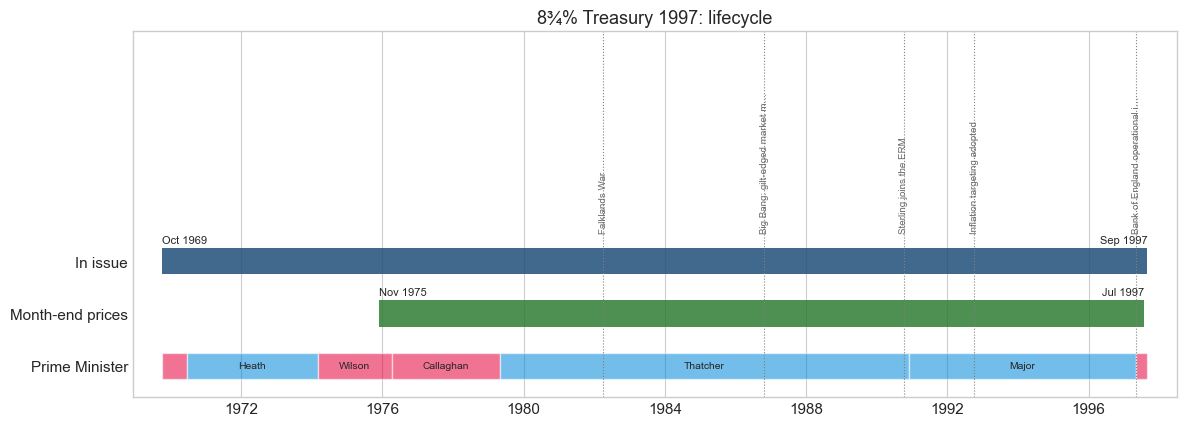

In [3]:
# Lifecycle timeline: life of the stock, price coverage, call window, prime ministers and key events
fig, ax = plt.subplots(figsize=(12, 2.6 + 0.6 * (len(LIFE_BARS) + 1)))
lo = min(mdates.date2num(pd.Timestamp(b[1])) for b in LIFE_BARS)
hi = max(mdates.date2num(pd.Timestamp(b[2])) for b in LIFE_BARS)
for k, (label, start, end, colour) in enumerate(LIFE_BARS):
    s, e = mdates.date2num(pd.Timestamp(start)), mdates.date2num(pd.Timestamp(end))
    ax.barh(k, max(e - s, 20), left=s, height=0.5, color=colour, alpha=0.85)
    ax.text(s, k - 0.32, f'{pd.Timestamp(start):%b %Y}', fontsize=8, ha='left', va='bottom')
    if e - s > (hi - lo) * 0.15:
        ax.text(e, k - 0.32, f'{pd.Timestamp(end):%b %Y}', fontsize=8, ha='right', va='bottom')
gy = len(LIFE_BARS)
for start, end, pm, party in GOVERNMENTS:
    s = max(mdates.date2num(pd.Timestamp(start)), lo)
    e = min(mdates.date2num(pd.Timestamp(end)), hi)
    if e <= s:
        continue
    ax.barh(gy, e - s, left=s, height=0.5, color=PARTY_COLOURS.get(party, '#cccccc'), alpha=0.55, edgecolor='white')
    if e - s > (hi - lo) * 0.05:
        ax.text((s + e) / 2, gy, pm, ha='center', va='center', fontsize=7.5)
ax.set_yticks(range(gy + 1))
ax.set_yticklabels([b[0] for b in LIFE_BARS] + ['Prime Minister'])
pad = (hi - lo) * 0.03
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(gy + 0.6, -4.4)          # leave room at the top for event labels
ax.xaxis_date()
for d, label in EVENTS.items():
    x = mdates.date2num(pd.Timestamp(d))
    if lo <= x <= hi:
        ax.axvline(x, color='grey', ls=':', lw=0.8)
        short = label if len(label) <= 30 else label[:29] + '…'
        ax.text(x, -0.55, short, rotation=90, ha='center', va='bottom', fontsize=7, color='dimgrey')
ax.set_title(f'{NAME}: lifecycle')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Issuance and Amount Outstanding

The nominal amount outstanding is recorded monthly from Oct 1969 to Aug 1997. It started at £400m, peaked at £5.55bn in Jan 1993 and ended at £5.55bn. Over the period the amount rose in 9 months (adding £5.15bn in all).

### Large changes

Months in which the amount changed by at least £50m and 5%. The classification is inferred from the data and the tranche records.

| Month | Change (£m) | Change | Outstanding after | Likely cause |
|---|---|---|---|---|
| Jan 1972 | +400 | +100% | £800m | Tranche A (ID 20200) amalgamated |
| Sep 1984 | +200 | +25% | £1.00bn | Further issue (tap, auction or syndication) |
| Mar 1986 | +150 | +15% | £1.15bn | Further issue (tap, auction or syndication) |
| Jun 1986 | +150 | +13% | £1.30bn | Further issue (tap, auction or syndication) |
| Jul 1987 | +1,100 | +85% | £2.40bn | Tranche B (ID 20300) amalgamated |
| Nov 1987 | +200 | +8% | £2.60bn | Further issue (tap, auction or syndication) |
| Jul 1988 | +1,000 | +38% | £3.60bn | Tranche C (ID 20400) amalgamated |
| Jul 1992 | +1,150 | +32% | £4.75bn | Tranche D (ID 20500) amalgamated |
| Jan 1993 | +800 | +17% | £5.55bn | Tranche E (ID 20600) amalgamated |


<!-- ENRICH: Explain the issuance history: how the stock was sold (tender, tap, auction or syndication), who bought the large further issues and why, and what caused the reductions (conversion offers, purchases by the National Debt Commissioners, buy-backs or redemption). -->

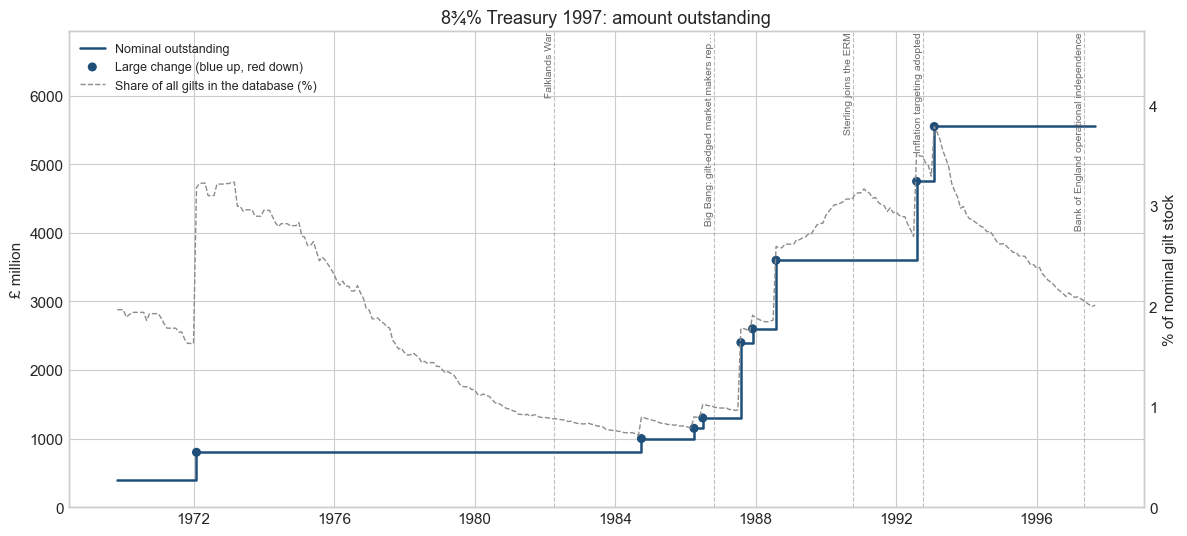

In [4]:
# Nominal amount outstanding; dots mark large changes (at least £50m and 5%)
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.step(quant.index, quant / 1e6, where='post', color=C_BOND, lw=1.8, label='Nominal outstanding')
if len(quant_ix):
    ax.step(quant_ix.index, quant_ix / 1e6, where='post', color=C_REAL, lw=1.4, label='Indexed (RPI-uplifted) outstanding')
full = quant.reindex(pd.date_range(quant.index[0], quant.index[-1], freq=pd.offsets.MonthEnd()))
dq = full.diff()
big = dq[dq.abs() >= np.maximum(50e6, 0.05 * full.shift(1))].dropna()
if len(big):
    ax.scatter(big.index, full.loc[big.index] / 1e6, c=np.where(big > 0, C_BOND, C_ACC), s=30, zorder=3,
               label='Large change (blue up, red down)')
ax.set_ylabel('£ million')
top = max(quant.max(), quant_ix.max() if len(quant_ix) else 0) / 1e6
ax.set_ylim(0, top * 1.25)
share = quant / gilt_stock_total(db).reindex(quant.index) * 100
ax2 = ax.twinx()
ax2.plot(share.index, share, color=C_PEER, lw=1, ls='--', label='Share of all gilts in the database (%)')
ax2.set_ylabel('% of nominal gilt stock')
ax2.set_ylim(0, share.max() * 1.25)
ax2.grid(False)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)
ax.set_title(f'{NAME}: amount outstanding')
mark_events(ax)
plt.tight_layout()
plt.show()

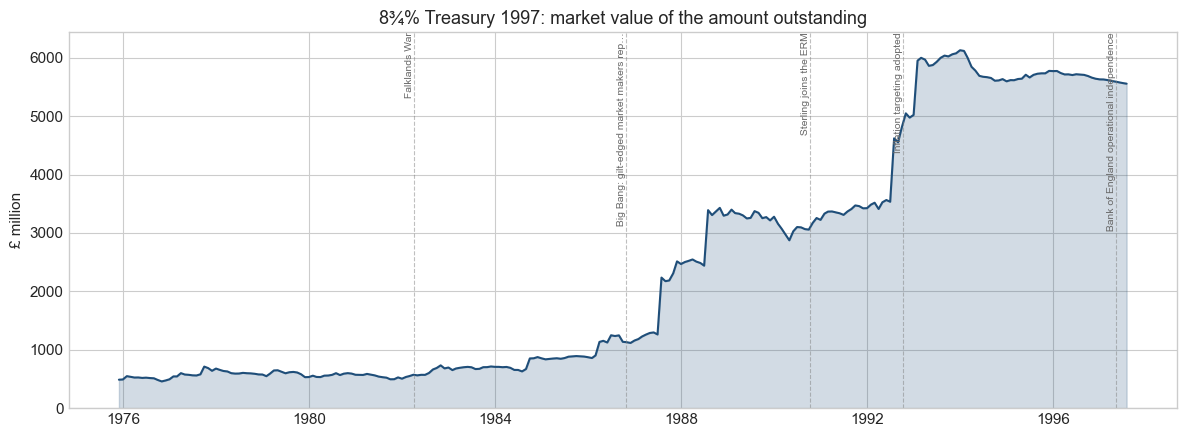

Market value: peak £6,129m (Dec 1993); last £5,556m (Jul 1997)


In [5]:
# Market value of the amount outstanding = price x nominal / 100 (new-style index-linked prices are real, so uplift them)
px = price.copy()
if info['Category L1'] == 'Index-linked' and not is_old_style_il(info, BOND_ID):
    px = px * index_ratio(db, BOND_ID, px.index).values
mv = (px * quant.reindex(px.index) / 100 / 1e6).dropna()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(mv.index, mv, color=C_BOND, alpha=0.2)
ax.plot(mv.index, mv, color=C_BOND, lw=1.5)
ax.set_ylabel('£ million')
ax.set_ylim(bottom=0)
ax.set_title(f'{NAME}: market value of the amount outstanding')
mark_events(ax)
plt.tight_layout()
plt.show()
print(f'Market value: peak £{mv.max():,.0f}m ({mv.idxmax():%b %Y}); last £{mv.iloc[-1]:,.0f}m ({mv.index[-1]:%b %Y})')

## Market Price

**Overall (Nov 1975 to Jul 1997):** mean £87.44, standard deviation 13.22, low £57.22 (Oct 1976), high £110.44 (Dec 1993); the stock was at or above par in 23% of months. Prices are month-end clean prices per £100 nominal (source prices before March 1986 converted from dirty to clean; see Data Notes).

**By era:**

| Era | Months | Obs | Mean | Min | Max | Mean yield |
|---|---|---|---|---|---|---|
| Competition and Credit Control and the Great Inflation | Nov 1975 - Apr 1979 | 42 | 71.45 | 57.22 | 88.92 | 12.83% |
| Monetarism, deregulation and the ERM | May 1979 - Sep 1992 | 161 | 85.70 | 61.80 | 101.34 | 11.02% |
| Inflation targeting and the 'NICE' decade | Oct 1992 - Jul 1997 | 58 | 103.84 | 100.11 | 110.44 | 6.87% |


<!-- ENRICH: Interpret the price path: the pull to par as redemption approached, the effect of the coupon relative to market yields, and the episodes behind the highs and lows. -->

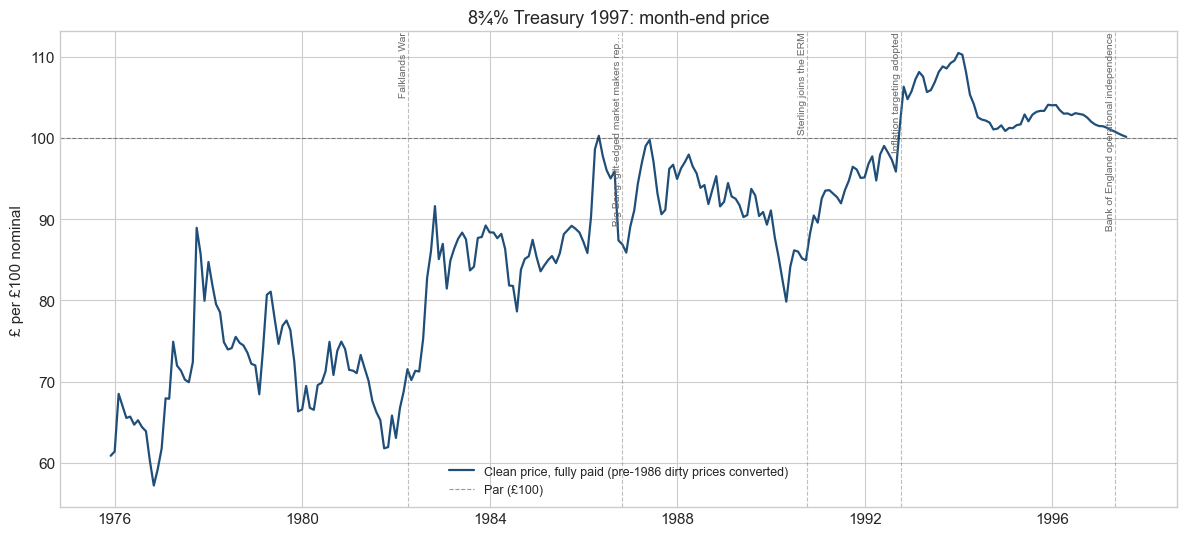

In [6]:
# Month-end clean price
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(price.index, price, color=C_BOND, lw=1.6, label=PRICE_LABEL)
if len(price_pp):
    ax.plot(price_pp.index, price_pp, color=C_ACC, lw=1.4, ls=':', label='Partly-paid price')
ax.axhline(100, color='black', lw=0.8, alpha=0.4, ls='--', label='Par (£100)')
ax.set_ylabel('£ per £100 nominal')
ax.set_title(f'{NAME}: month-end price')
ax.legend(loc='best', fontsize=9)
mark_events(ax)
plt.tight_layout()
plt.show()

## Yield and Relative Value

The yield shown is the gross redemption yield: the discount rate that equates the price plus accrued interest to the remaining coupons and principal, compounded semi-annually. Peers are conventional gilts whose remaining life is within 15% (at least one year) of this stock's, measured the same way; yields within three months of redemption are dropped.

The gross redemption yield was 14.81% in Nov 1975 and 6.53% in May 1997; it peaked at 15.80% (Oct 1976) and was lowest at 5.56% (Dec 1993). Against the peer median (typically 13 stocks) the spread averaged -27 bp (median -20 bp); the stock yielded less than its peers - traded 'rich' - in 95% of months. The widest spreads were +14 bp (Nov 1975) and -99 bp (Sep 1981).

| Era | Months | Mean spread (bp) |
|---|---|---|
| Competition and Credit Control and the Great Inflation | 42 | -21 |
| Monetarism, deregulation and the ERM | 161 | -35 |
| Inflation targeting and the 'NICE' decade | 56 | -9 |


<!-- ENRICH: Explain the level of the yield relative to peers: coupon and tax effects, liquidity (size, benchmark status), call features, index-linked demand from pension funds, or episodes of official buying and selling. -->

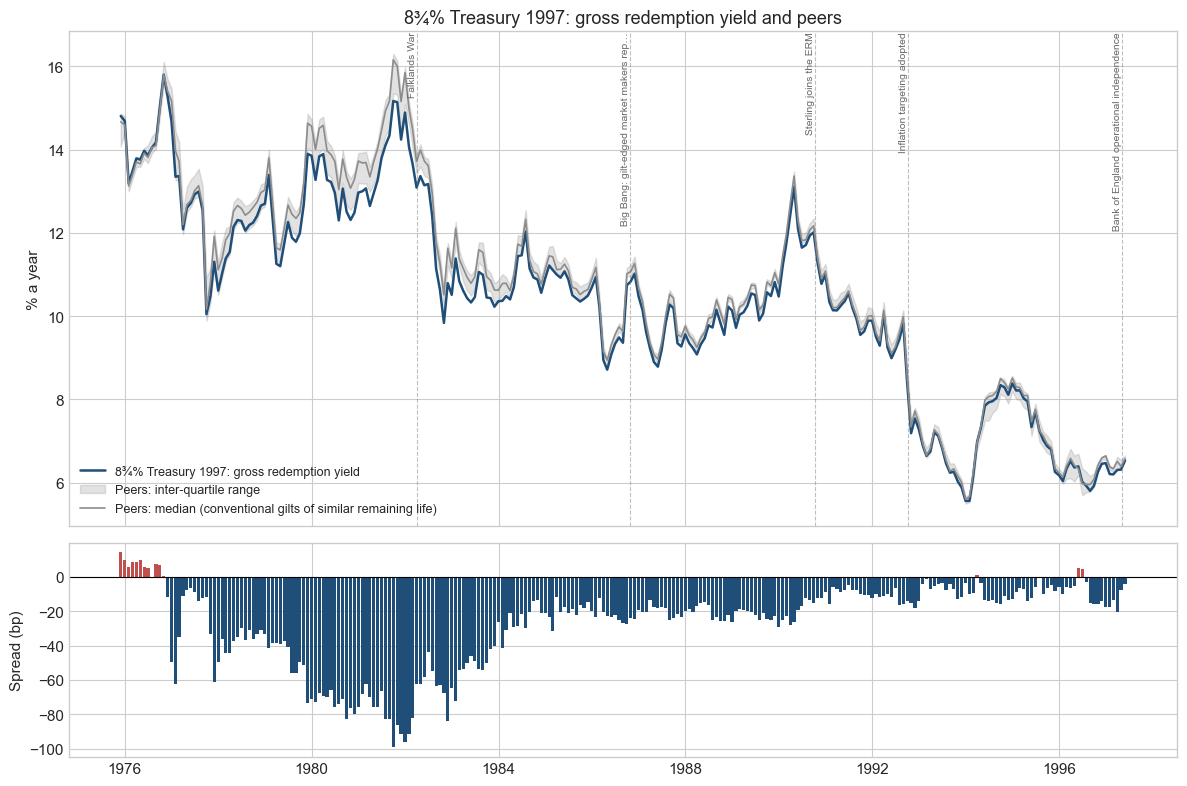

In [7]:
# Yield against the peer group; lower panel = spread over the peer median (positive = cheaper than peers)
y = yields['yield'].dropna()
has_peers = len(peers) > 0
if has_peers:
    fig, (ax, axs) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1.3]})
else:
    fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(y.index, y, color=C_BOND, lw=1.8, label=f'{NAME}: {YIELD_LABEL.lower()}')
if has_peers:
    ax.fill_between(peers.index, peers['q25'], peers['q75'], color=C_PEER, alpha=0.25, label='Peers: inter-quartile range')
    ax.plot(peers.index, peers['median'], color=C_PEER, lw=1.2, label=f'Peers: median ({PEER_LABEL})')
    spread = ((y - peers['median']) * 100).dropna()
    axs.bar(spread.index, spread, width=25, color=np.where(spread > 0, C_ACC, C_BOND))
    axs.axhline(0, color='black', lw=0.8)
    axs.set_ylabel('Spread (bp)')
ax.set_ylabel('% a year')
ax.set_title(f'{NAME}: {YIELD_LABEL.lower()} and peers')
ax.legend(loc='best', fontsize=9)
mark_events(ax)
plt.tight_layout()
plt.show()

## On the Yield Curve

Snapshots of every gilt in the peer group on 2 dates: Nov 1975 (first priced month and highest yield); May 1997 (last priced month). The grey line is a Nelson-Siegel curve fitted to the other gilts; the distance of the star from the line shows whether the stock was cheap (above) or rich (below) relative to the curve.

<!-- ENRICH: Comment on the shape of the curve at each date (upward-sloping, flat or inverted) and what it says about monetary policy and inflation expectations at the time. -->

Nov 1975: yield 14.81%, fitted curve 14.17%, residual +64 bp
May 1997: yield 6.53%, fitted curve 6.42%, residual +11 bp


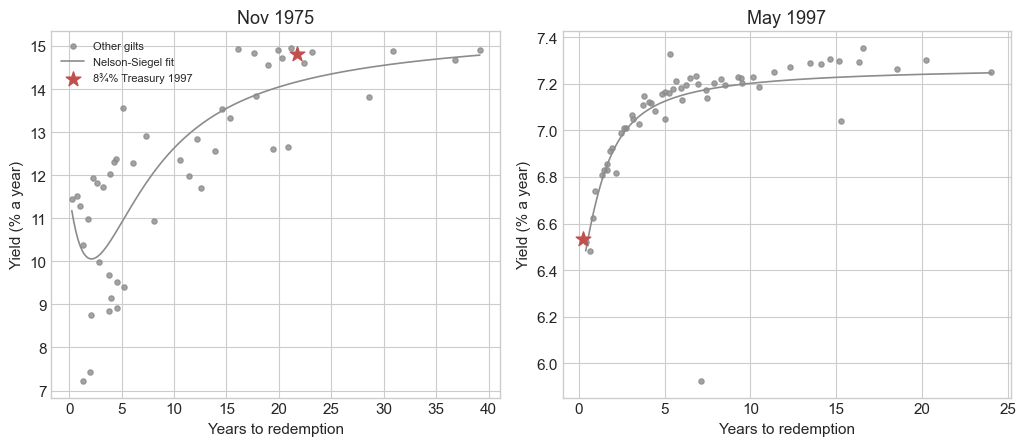

In [8]:
# The stock on the yield curve: every peer-group gilt on each date, with a fitted Nelson-Siegel curve
fig, axes = plt.subplots(1, len(SNAPSHOTS), figsize=(5.2 * len(SNAPSHOTS), 4.6), squeeze=False)
for ax, d in zip(axes[0], SNAPSHOTS):
    d = pd.Timestamp(d)
    pts = pd.DataFrame([(v.at[d, 'remaining'], v.at[d, 'yield']) for k, v in panel.items()
                        if k != BOND_ID and d in v.index], columns=['T', 'y']).dropna()
    ax.scatter(pts['T'], pts['y'], s=14, color=C_PEER, alpha=0.8, label='Other gilts')
    curve = nelson_siegel(pts['T'], pts['y'])
    if curve is not None:
        tt = np.linspace(max(0.25, pts['T'].min()), pts['T'].max(), 200)
        ax.plot(tt, curve(tt), color=C_PEER, lw=1.2, label='Nelson-Siegel fit')
    own = yields.loc[d]
    T_own = own['remaining'] if pd.notna(own.get('remaining', np.nan)) else pts['T'].max() + 3
    ax.scatter([T_own], [own['yield']], s=120, marker='*', color=C_ACC, zorder=3, label=NAME)
    if curve is not None and pd.notna(own.get('remaining', np.nan)):
        print(f"{d:%b %Y}: yield {own['yield']:.2f}%, fitted curve {float(curve(T_own)):.2f}%, "
              f"residual {100 * (own['yield'] - float(curve(T_own))):+.0f} bp")
    ax.set_title(f'{d:%b %Y}')
    ax.set_xlabel('Years to redemption' + (' (undated shown at right)' if pd.isna(own.get('remaining', np.nan)) else ''))
    ax.set_ylabel('Yield (% a year)')
axes[0][0].legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

## Returns and Risk to Holders

An investor who bought at the first month-end price (Nov 1975) and reinvested every coupon held 14.98 times the starting value by Jul 1997: 13.31% a year in nominal terms over 21.7 years. In real terms (deflating by the RPI from Mar 1980) the return was 7.08% a year, a cumulative factor of 3.27. Returns were volatile at 11.7% a year; the worst fall from a previous peak was -12.4% (Apr 1979 to Nov 1979). Twelve-month volatility peaked at 28.7% a year around Dec 1977.

*Method: monthly return = (change in price + coupon accrued over the month) ÷ previous price, with index-linked coupons and new-style prices uplifted by the index ratio. Taxes and dealing costs are ignored; partly-paid months are excluded.*

<!-- ENRICH: Put the returns in perspective: compare with inflation, Bank Rate and equities over the same years (e.g. Dimson, Marsh and Staunton 2002), and ask who gained and who lost - the Treasury or the holders. -->

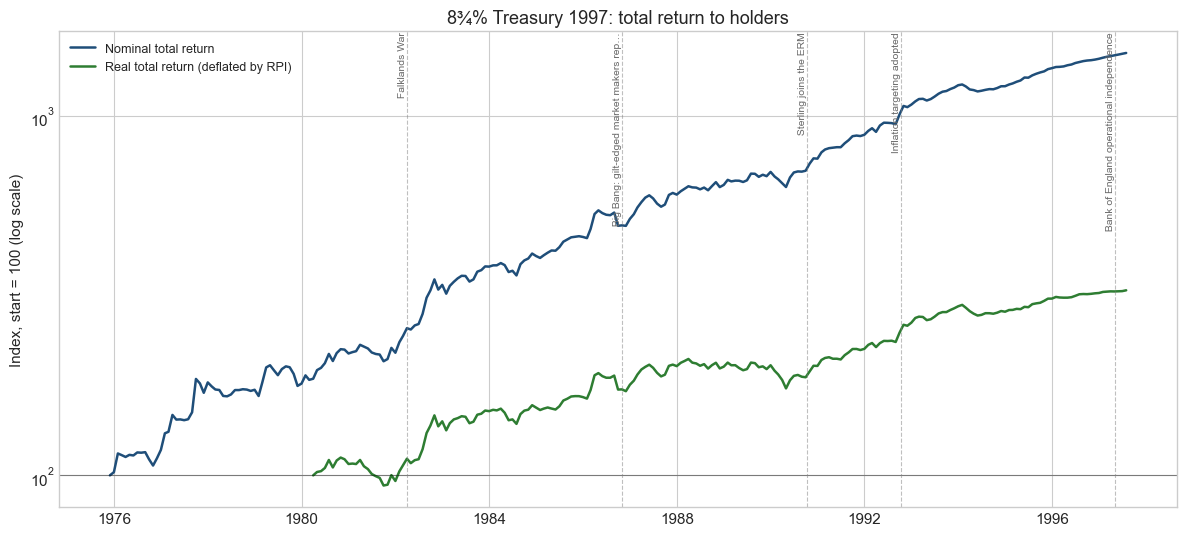

Nominal: x14.98 over 21.7 years = 13.31% a year
Real (from Mar 1980): x3.27 = 7.08% a year


In [9]:
# Total return to a holder who bought at the first month-end price and reinvested coupons
tr = total_return_index(db, BOND_ID)
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(tr.index, tr['nominal'], color=C_BOND, lw=1.8, label='Nominal total return')
if 'real' in tr and tr['real'].notna().any():
    ax.plot(tr.index, tr['real'], color=C_REAL, lw=1.8, label='Real total return (deflated by RPI)')
ax.axhline(100, color='black', lw=0.8, alpha=0.4)
ax.set_yscale('log')
ax.set_ylabel('Index, start = 100 (log scale)')
ax.set_title(f'{NAME}: total return to holders')
ax.legend(loc='upper left', fontsize=9)
mark_events(ax)
plt.tight_layout()
plt.show()
yrs = (tr.index[-1] - tr.index[0]).days / 365.25
print(f"Nominal: x{tr['nominal'].iloc[-1] / 100:.2f} over {yrs:.1f} years = "
      f"{100 * ((tr['nominal'].iloc[-1] / 100) ** (1 / yrs) - 1):.2f}% a year")
if 'real' in tr and tr['real'].notna().sum() > 12:
    rr = tr['real'].dropna()
    ry = (rr.index[-1] - rr.index[0]).days / 365.25
    print(f"Real (from {rr.index[0]:%b %Y}): x{rr.iloc[-1] / rr.iloc[0]:.2f} = "
          f"{100 * ((rr.iloc[-1] / rr.iloc[0]) ** (1 / ry) - 1):.2f}% a year")

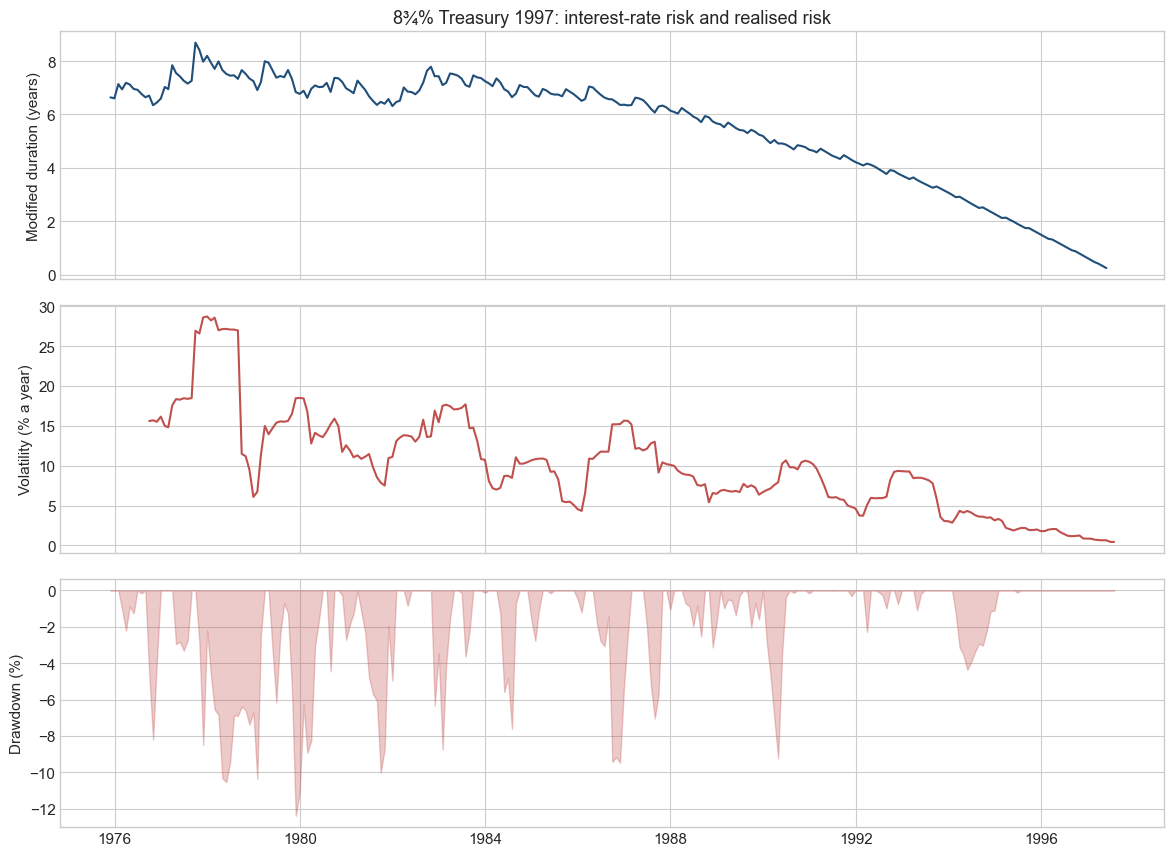

In [10]:
# Risk: modified duration, rolling 12-month volatility of monthly returns, and drawdown from the previous peak
ret = tr['nominal'].pct_change()
vol = ret.rolling(12, min_periods=10).std() * np.sqrt(12) * 100
dd = (tr['nominal'] / tr['nominal'].cummax() - 1) * 100
dur = yields['duration'].dropna() if 'duration' in yields else pd.Series(dtype=float)
panels = [p for p in ('dur', 'vol', 'dd') if p != 'dur' or len(dur)]
fig, axes = plt.subplots(len(panels), 1, figsize=(12, 2.9 * len(panels)), sharex=True, squeeze=False)
for ax, p in zip(axes[:, 0], panels):
    if p == 'dur':
        ax.plot(dur.index, dur, color=C_BOND, lw=1.5)
        ax.set_ylabel('Modified duration (years)')
    elif p == 'vol':
        ax.plot(vol.index, vol, color=C_ACC, lw=1.5)
        ax.set_ylabel('Volatility (% a year)')
    else:
        ax.fill_between(dd.index, dd, 0, color=C_ACC, alpha=0.3)
        ax.set_ylabel('Drawdown (%)')
axes[0, 0].set_title(f'{NAME}: interest-rate risk and realised risk')
plt.tight_layout()
plt.show()

## Market Events

Months in which the price moved by 5% or more, or the stock's yield moved at least 40 basis points more than the median yield of its peers (the twelve largest, in date order). Comparing yield changes with maturity-matched peers separates moves specific to this stock from market-wide moves. The nearest event in the knowledge base is listed as a lead, not as a cause.

| Month | Price change | Yield change (bp) | Peer median change (bp) | Relative (bp) | Nearest event |
|---|---|---|---|---|---|
| Jan 1976 | +11.5% | -151 | -147 | -4 | Secondary banking crisis ('Lifeboat') (Dec 1973 - Dec 1975) |
| Jan 1977 | +10.0% | -133 | -120 | -12 | IMF crisis (28 September 1976 - 15 December 1976) |
| Mar 1977 | +10.3% | -128 | -152 | +24 | Minimum Lending Rate cut from 15% to 5% (Jan 1977 - Oct 1977) |
| Sep 1977 | +22.8% | -250 | -251 | +1 | Minimum Lending Rate cut from 15% to 5% (Jan 1977 - Oct 1977) |
| Nov 1977 | -6.7% | +83 | +111 | -28 | Minimum Lending Rate cut from 15% to 5% (Jan 1977 - Oct 1977) |
| Feb 1979 | +7.8% | -99 | -102 | +3 | Winter of Discontent (Nov 1978 - Feb 1979) |
| Mar 1979 | +9.4% | -114 | -114 | +0 | Winter of Discontent (Nov 1978 - Feb 1979) |
| Nov 1979 | -8.4% | +122 | +144 | -22 | Minimum Lending Rate raised to 17% (15 November 1979) |
| Aug 1982 | +9.9% | -127 | -118 | -9 | Falklands War (2 April 1982 - 14 June 1982) |
| Nov 1982 | -7.1% | +96 | +112 | -16 | none in the knowledge base |
| Mar 1986 | +9.3% | -127 | -118 | -8 | Oil-price collapse (Jan 1986 - Apr 1986) |
| Sep 1986 | -8.9% | +138 | +139 | -1 | none in the knowledge base |


<!-- ENRICH: Explain these moves. Separate market-wide shocks (where the peers moved too) from moves specific to this stock (conversion offers, taps, calls, index-linking news, tax changes, redemption announcements). -->

## Related Stocks

**Tranche family**

| ID | Stock | First issued | Maturity | Relationship | Price months |
|---|---|---|---|---|---|
| 20200 | 8¾% Treasury 1997 A | 13 July 1971 | 1 September 1997 | Tranche A | 0 |
| 20300 | 8¾% Treasury 1997 B | 9 March 1987 | 1 September 1997 | Tranche B | 2 |
| 20400 | 8¾% Treasury 1997 C | 13 January 1988 | 1 September 1997 | Tranche C | 5 |
| 20500 | 8¾% Treasury 1997 D | 1 May 1992 | 1 September 1997 | Tranche D | 1 |
| 20600 | 8¾% Treasury 1997 E | 9 October 1992 | 1 September 1997 | Tranche E | 0 |

**Same category and decade**

| ID | Stock | First issued | Maturity | Relationship | Price months |
|---|---|---|---|---|---|
| 20000 | 7% Treasury Convertible 1997 | 26 May 1994 | 6 August 1997 | same maturity decade | 39 |
| 20700 | 15% Exchequer 1997 | 14 October 1981 | 27 October 1997 | same maturity decade | 191 |
| 20800 | 9¾% Exchequer 1998 | 8 February 1984 | 19 January 1998 | same maturity decade | 165 |
| 19900 | 10½% Exchequer 1997 | 20 October 1977 | 21 February 1997 | same maturity decade | 231 |
| 21000 | 7¼% Treasury 1998 | 23 October 1992 | 30 March 1998 | same maturity decade | 62 |
| 19700 | 13¼% Treasury 1997 | 17 July 1975 | 22 January 1997 | same maturity decade | 254 |

**Issued within a year**

| ID | Stock | First issued | Maturity | Relationship | Price months |
|---|---|---|---|---|---|
| 18100 | 9% Treasury 1994 | 23 July 1969 | 17 November 1994 | contemporary | 228 |
| 7700 | 8½% Treasury 1980-82 | 28 January 1970 | 15 January 1982 | contemporary | 73 |
| 3100 | 6¾% Treasury 1974 | 12 August 1970 | 11 December 1974 | contemporary | 0 |
| 11500 | 8½% Treasury 1984-86 | 12 August 1970 | 10 July 1986 | contemporary | 127 |

**Same coupon**

| ID | Stock | First issued | Maturity | Relationship | Price months |
|---|---|---|---|---|---|
| 8600 | 8¾% Exchequer 1983 | 2 March 1978 | 5 January 1983 | same coupon | 57 |
| 10700 | 8¾% Treasury Convertible 1985 | 4 November 1982 | 3 September 1985 | same coupon | 31 |
| 31600 | 8¾% Treasury 2017 | 30 April 1992 | 25 August 2017 | same coupon | 302 |



<!-- ENRICH: Compare this stock with its closest relatives: why did the Treasury issue these stocks side by side, and how did coupon, maturity or special terms make them trade differently? -->

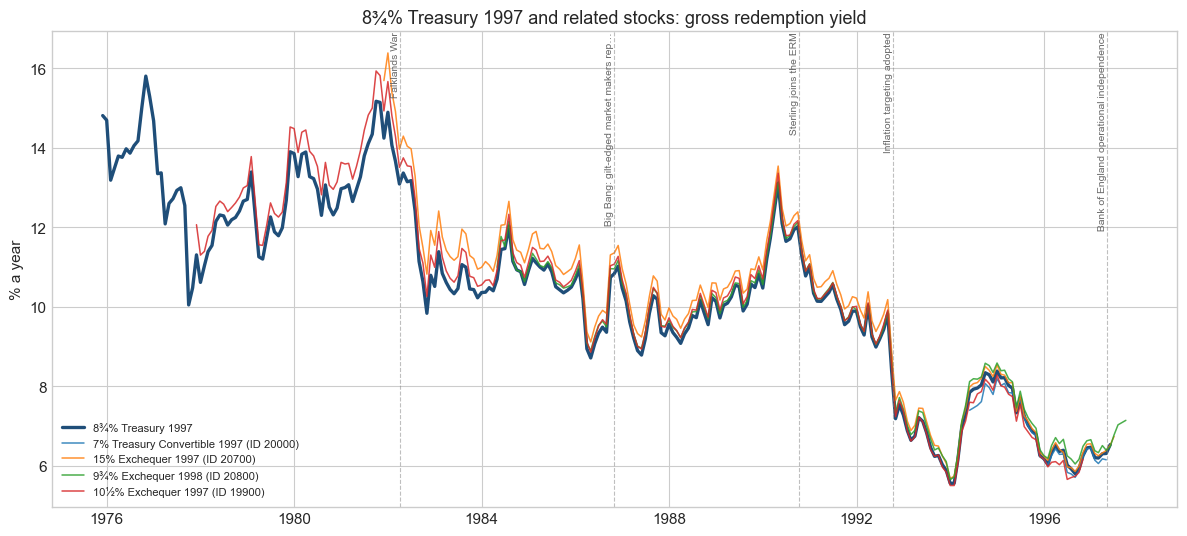

In [11]:
# Yields of related stocks, measured the same way
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(yields.index, yields['yield'], color=C_BOND, lw=2.4, label=NAME)
for k, name in RELATED.items():
    yk = bond_yields(db, k)['yield'].dropna()
    ax.plot(yk.index, yk, lw=1.1, alpha=0.85, label=f'{name} (ID {k})')
ax.set_ylabel('% a year')
ax.set_title(f'{NAME} and related stocks: {YIELD_LABEL.lower()}')
ax.legend(loc='best', fontsize=8)
mark_events(ax)
plt.tight_layout()
plt.show()

## Issuance, Distribution and Redemption

Stocks of this period were sold mainly through the Bank of England's tap system: the Bank took up new issues and the Government Broker sold them to the market (to the jobbers before October 1986, then to gilt-edged market makers) at prices set by the Bank, when demand allowed.

The stock was redeemed on 1 September 1997.

<!-- ENRICH: Describe who held the stock (banks, insurance companies, pension funds, overseas holders, the Bank of England and, after 2009, the Asset Purchase Facility) and how its redemption was financed. -->

## Implications and Legacy

- What does this stock's history reveal about how the British state borrowed in its era?
- Holders earned 7.1% a year in real terms: who bore the cost of inflation, and was this part of a policy of 'financial repression' or inflating away the debt?

<!-- ENRICH: Write 2-3 paragraphs answering these questions, linking the stock to the long-run themes of Ellison and Scott (2020): the maturity structure of the debt, the cost of financing, and the interaction of debt management with monetary policy. -->

## Data Notes

**Source:** BGSDetails / BGSAmounts / BGSPrices (Ellison-Scott database, as assembled in `UK_Gilts_Bond_Database.xlsx`).

**Corrections applied to the source files that affect this stock:**

| Item | Month / date | Original | New | Reason |
|---|---|---|---|---|
| Average price | 1987-04 | missing | 99 | Missing ('missing') in BGSPrices; value from Prices_RE (hand-entered from FT). |
| Average price | 1987-11 | missing | 96.6875 | Missing ('missing') in BGSPrices; value from Prices_RE (hand-entered from FT). |


**Caveats:**

- Prices are month-end clean prices per £100 nominal; amounts are month-end nominal amounts outstanding in £.
- Yields are computed in this chapter from the prices and terms (actual coupon dates, accrued interest); they can differ slightly from officially published yields.
- The October 2022 prices in the source files were copies of September 2022 and have been removed.
- Before 28 February 1986 the source quotes stocks with more than five years to maturity (and undated stocks) with accrued interest included - their prices drop by about half a coupon when they go ex-dividend. This chapter converts those prices to a clean basis (subtracting accrued interest, or adding rebate interest when ex-dividend) before computing prices, yields and returns; `series(db, 'price', BOND_ID, 'Average')` gives the source prices.

## References

- Ellison, Martin and Andrew Scott (2020). "Managing the UK National Debt 1694-2018." *American Economic Journal: Macroeconomics* 12(3): 227-257.
- Kynaston, David (2017). *Till Time's Last Sand: A History of the Bank of England 1694-2013*. London: Bloomsbury.
- Dimson, Elroy, Paul Marsh and Mike Staunton (2002). *Triumph of the Optimists: 101 Years of Global Investment Returns*. Princeton: Princeton University Press.
- Hall, George J., Jonathan Payne and Thomas J. Sargent (2018). "US Federal Debt 1776-1960: Quantities and Prices." Working paper (the US database behind the companion bond biographies).
- UK Debt Management Office. *Formulae for Calculating Gilt Prices from Yields* (editions from 1998).
- Pember & Boyle (1950). *British Government Securities in the Twentieth Century*, 2nd ed.; supplement 1950-1976 (1976). London: privately printed.
- Allen, William A. (2019). *The Bank of England and the Government Debt: Operations in the Gilt-Edged Market, 1928-1972*. Cambridge: Cambridge University Press.
- Reinhart, Carmen M. and M. Belen Sbrancia (2015). "The Liquidation of Government Debt." *Economic Policy* 30(82): 291-333.
- Capie, Forrest (2010). *The Bank of England: 1950s to 1979*. Cambridge: Cambridge University Press.
- Needham, Duncan (2014). *UK Monetary Policy from Devaluation to Thatcher, 1967-82*. Basingstoke: Palgrave Macmillan.
- HM Treasury and Bank of England (1995). *Report of the Debt Management Review*. London: HM Treasury.

<!-- ENRICH: Add specific sources for this stock: the prospectus or Treasury announcement, Bank of England Quarterly Bulletin commentary, Hansard debates, and DMO or Bank records. -->